# Week 2 lab: Generalization & Validation

AIE683 Machine Learning, Hacettepe University.

In this lab you will

1. fit k-nearest neighbors on a real medical dataset and see how `n_neighbors` controls model complexity,
2. choose hyper-parameters with a validation set, with cross-validation and with `GridSearchCV`,
3. log a hyper-parameter sweep to MLflow,
4. compare cross-validation strategies, including `GroupKFold` and `TimeSeriesSplit`,
5. work through the two in-class exercises (**Try it 1** and **Try it 2**).

Run the cells top to bottom. Exercise sections are marked **EXERCISE** and contain `TODO` comments;
they run as provided, so you can execute the whole notebook first and then come back to them.
Inspect your MLflow runs with `uv run mlflow ui` from this folder.

In [1]:
import logging
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     GridSearchCV, KFold, StratifiedKFold, ShuffleSplit,
                                     RepeatedStratifiedKFold, GroupKFold, TimeSeriesSplit)

%matplotlib inline
logging.getLogger("mlflow").setLevel(logging.WARNING)
np.set_printoptions(precision=2)
pd.set_option("display.width", 120)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data: breast cancer diagnosis

569 tumors described by 30 measurements from digitized images of a fine-needle aspirate; the target is malignant (0) or benign (1).

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data.to_numpy(), data.target.to_numpy()
print(X.shape, np.bincount(y))

(569, 30) [212 357]


## 2. kNN with a train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
print(f"test accuracy (k=1): {knn.score(X_test, y_test):.3f}")
print(f"train accuracy (k=1): {knn.score(X_train, y_train):.3f}")

test accuracy (k=1): 0.916
train accuracy (k=1): 1.000


## 3. Model complexity

Training and test accuracy for different `n_neighbors`. Small k = complex model (low bias, high variance).

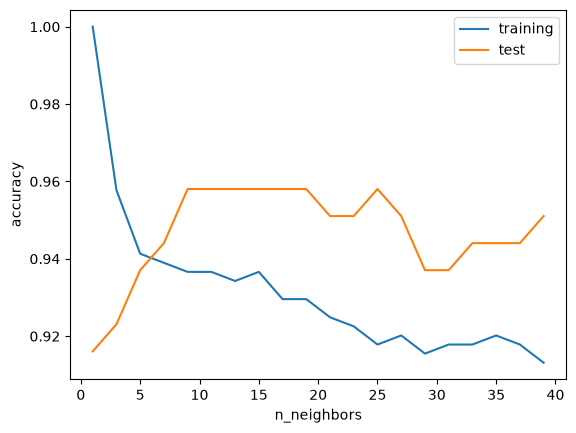

In [4]:
neighbors = range(1, 40, 2)
train_scores, test_scores = [], []
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

plt.plot(neighbors, train_scores, label="training")
plt.plot(neighbors, test_scores, label="test")
plt.xlabel("n_neighbors")
plt.ylabel("accuracy")
plt.legend();

## 4. Threefold split: train / validation / test

In [5]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, random_state=0)

val_scores = []
neighbors = np.arange(1, 15, 2)
for i in neighbors:
    knn = KNeighborsClassifier(n_neighbors=i).fit(X_train, y_train)
    val_scores.append(knn.score(X_val, y_val))
print(f"best validation score: {np.max(val_scores):.3f}")
best_n_neighbors = neighbors[np.argmax(val_scores)]
print("best n_neighbors:", best_n_neighbors)

knn = KNeighborsClassifier(n_neighbors=best_n_neighbors).fit(X_trainval, y_trainval)
print(f"test-set score: {knn.score(X_test, y_test):.3f}")

best validation score: 0.925
best n_neighbors: 5
test-set score: 0.937


## 5. Cross-validation for choosing n_neighbors

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

cross_val_scores = []
for i in neighbors:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=i), X_train, y_train, cv=10)
    cross_val_scores.append(np.mean(scores))

print(f"best cross-validation score: {np.max(cross_val_scores):.3f}")
best_n_neighbors = neighbors[np.argmax(cross_val_scores)]
print(f"best n_neighbors: {best_n_neighbors}")

knn = KNeighborsClassifier(n_neighbors=best_n_neighbors).fit(X_train, y_train)
print(f"test-set score: {knn.score(X_test, y_test):.3f}")

best cross-validation score: 0.927
best n_neighbors: 7
test-set score: 0.944


## 6. GridSearchCV

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

param_grid = {'n_neighbors': list(range(1, 30, 2))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=10,
                    return_train_score=True)
grid.fit(X_train, y_train)
print(f"best mean cross-validation score: {grid.best_score_:.3f}")
print(f"best parameters: {grid.best_params_}")
print(f"test-set score: {grid.score(X_test, y_test):.3f}")

best mean cross-validation score: 0.944
best parameters: {'n_neighbors': 5}
test-set score: 0.916


In [8]:
results = pd.DataFrame(grid.cv_results_)
results[["param_n_neighbors", "mean_train_score", "mean_test_score", "std_test_score",
         "rank_test_score"]].head(8)

,param_n_neighbors,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,1,1.000000,0.924806,0.037955,14
1,3,0.957747,0.938926,0.019061,6
2,5,0.946270,0.943632,0.015774,1
3,7,0.944965,0.941307,0.018969,3
4,9,0.942097,0.941307,0.015864,3
5,11,0.940010,0.941362,0.024084,2
6,13,0.940533,0.934275,0.013993,8
7,15,0.937924,0.934275,0.013993,8


## 7. Logging the k sweep to MLflow

Each value of `n_neighbors` becomes a nested child run under one parent run. We log mean and standard deviation of the CV accuracy, the individual fold scores (`step=fold`), and how the scores were computed.

In [9]:
mlflow.set_experiment("week02-generalization-validation")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
with mlflow.start_run(run_name="knn-k-sweep"):
    mlflow.log_params({"dataset": "breast_cancer", "cv": "StratifiedKFold(10, shuffle)",
                       "n_train": len(X_train)})
    for k in [1, 3, 5, 9, 15, 25]:
        scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=cv)
        with mlflow.start_run(run_name=f"k={k}", nested=True):
            mlflow.log_param("n_neighbors", k)
            mlflow.log_metrics({"cv_accuracy_mean": scores.mean(),
                                "cv_accuracy_std": scores.std()})
            for fold, s in enumerate(scores):
                mlflow.log_metric("cv_accuracy_fold", s, step=fold)
        print(f"k={k:2d}: {scores.mean():.3f} +/- {scores.std():.3f}")

k= 1: 0.915 +/- 0.044
k= 3: 0.927 +/- 0.038
k= 5: 0.932 +/- 0.041
k= 9: 0.934 +/- 0.053
k=15: 0.934 +/- 0.049
k=25: 0.925 +/- 0.045


In [10]:
runs = mlflow.search_runs(experiment_names=["week02-generalization-validation"],
                          filter_string="params.n_neighbors != ''", max_results=6)
runs[["params.n_neighbors", "metrics.cv_accuracy_mean", "metrics.cv_accuracy_std"]]

,params.n_neighbors,metrics.cv_accuracy_mean,metrics.cv_accuracy_std
0,25,0.924806,0.044630
1,15,0.934275,0.049210
2,9,0.934330,0.053470
3,5,0.932004,0.041046
4,3,0.927187,0.038380
5,1,0.915393,0.043577


---
## EXERCISE (Try it 1): Beat the held-out set

**In class, about 15 minutes, in pairs.** A held-out set (`X_hold`, `y_hold`) plays the role of future data. You may only use `X_dev`, `y_dev` for decisions.

1. Choose a kNN configuration using cross-validation on the development data only. Things to try: `n_neighbors`, `weights` (`"uniform"` / `"distance"`), `p` (1 = Manhattan, 2 = Euclidean).
2. Write down your **CV estimate** before you look at the held-out score.
3. Set `I_WROTE_DOWN_MY_ESTIMATE = True` and run the held-out cell **once**. How far was your estimate from the held-out score? Did the pair with the best CV score also win on the held-out set?
4. The held-out cell logs your configuration, CV estimate and held-out score to MLflow.

In [11]:
# EXERCISE (Try it 1): development / held-out split -- do not change
X_dev, X_hold, y_dev, y_hold = train_test_split(X, y, test_size=0.3, stratify=y, random_state=2026)
cv_dev = StratifiedKFold(5, shuffle=True, random_state=0)

In [12]:
# EXERCISE (Try it 1)
# TODO: change the configuration below (or run a GridSearchCV on X_dev, y_dev with cv=cv_dev)
my_model = KNeighborsClassifier(n_neighbors=5, weights="uniform", p=2)

cv_scores = cross_val_score(my_model, X_dev, y_dev, cv=cv_dev)
print(f"my CV estimate: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

my CV estimate: 0.932 +/- 0.018


In [13]:
# TODO: set to True once you have written down your CV estimate
I_WROTE_DOWN_MY_ESTIMATE = False

In [14]:
# EXERCISE (Try it 1): held-out evaluation -- run ONCE
if not I_WROTE_DOWN_MY_ESTIMATE:
    print("Write down your CV estimate first, then set I_WROTE_DOWN_MY_ESTIMATE = True and rerun.")
else:
    hold_score = my_model.fit(X_dev, y_dev).score(X_hold, y_hold)
    print(f"CV estimate: {cv_scores.mean():.3f}   held-out accuracy: {hold_score:.3f}")
    with mlflow.start_run(run_name="try-it-1"):
        mlflow.log_params(my_model.get_params())
        mlflow.log_metrics({"cv_accuracy_mean": cv_scores.mean(),
                            "holdout_accuracy": hold_score})

Write down your CV estimate first, then set I_WROTE_DOWN_MY_ESTIMATE = True and rerun.


## 8. Importance of stratification

A dataset with 60% / 40% classes and a classifier that always predicts the majority class (true accuracy 0.6).

In [15]:
rng = np.random.RandomState(0)
X_s = rng.normal(size=(100, 2))
y_s = np.zeros(100, int)
y_s[:40] = 1

dc = DummyClassifier(strategy='most_frequent')
for name, cv in [("StratifiedKFold", StratifiedKFold(5, shuffle=True, random_state=0)),
                 ("KFold", KFold(5, shuffle=True, random_state=0))]:
    res = cross_val_score(dc, X_s, y_s, cv=cv)
    print(f"{name:16s} mean={res.mean():.3f}, std={res.std():.3f}")

StratifiedKFold  mean=0.600, std=0.000
KFold            mean=0.600, std=0.138


## 9. Using cross-validation generators

In [16]:
kfold = KFold(n_splits=5)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
ss = ShuffleSplit(n_splits=20, train_size=.4, test_size=.3, random_state=0)
rs = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

print("KFold:\n", cross_val_score(KNeighborsClassifier(), X, y, cv=kfold))
print("StratifiedKFold:\n", cross_val_score(KNeighborsClassifier(), X, y, cv=skfold))
print("ShuffleSplit:\n", cross_val_score(KNeighborsClassifier(), X, y, cv=ss))
print("RepeatedStratifiedKFold:\n", cross_val_score(KNeighborsClassifier(), X, y, cv=rs))

KFold:
 [0.86 0.92 0.96 0.95 0.94]
StratifiedKFold:
 [0.92 0.94 0.92 0.91 0.96]


ShuffleSplit:
 [0.96 0.92 0.9  0.91 0.94 0.92 0.93 0.89 0.95 0.95 0.91 0.94 0.93 0.94
 0.93 0.97 0.91 0.93 0.94 0.92]
RepeatedStratifiedKFold:
 [0.92 0.94 0.92 0.91 0.96 0.96 0.95 0.92 0.91 0.95 0.95 0.96 0.92 0.92
 0.91 0.91 0.95 0.92 0.91 0.96 0.92 0.94 0.92 0.95 0.92 0.91 0.95 0.96
 0.94 0.93 0.91 0.92 0.94 0.93 0.91 0.93 0.93 0.89 0.95 0.94 0.94 0.96
 0.92 0.94 0.91 0.95 0.88 0.91 0.95 0.93]


In [17]:
res = cross_validate(KNeighborsClassifier(), X, y, return_train_score=True,
                     scoring=["accuracy", "roc_auc"])
pd.DataFrame(res).round(3)

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc
0,0.0,0.002,0.886,0.952,0.946,0.992
1,0.0,0.001,0.939,0.952,0.953,0.992
2,0.0,0.001,0.939,0.947,0.981,0.991
3,0.0,0.001,0.947,0.938,0.963,0.990
4,0.0,0.001,0.929,0.947,0.955,0.992


## 10. Grouped data: KFold vs. GroupKFold

A simulation of repeated measurements: 20 patients with 30 measurements each. All measurements of a patient share that patient's profile and diagnosis. Random `KFold` lets the model see other measurements of the test patient; `GroupKFold` measures how well we generalize to *new* patients.

In [18]:
rng = np.random.RandomState(0)
n_patients, n_per_patient = 20, 30
patient_profile = rng.normal(size=(n_patients, 5))
patient_label = rng.randint(0, 2, size=n_patients)

patient_id = np.repeat(np.arange(n_patients), n_per_patient)
X_p = patient_profile[patient_id] + 0.3 * rng.normal(size=(len(patient_id), 5))
y_p = patient_label[patient_id]

knn = KNeighborsClassifier(n_neighbors=5)
kf = cross_val_score(knn, X_p, y_p, cv=KFold(5, shuffle=True, random_state=0))
gkf = cross_val_score(knn, X_p, y_p, groups=patient_id, cv=GroupKFold(5))
print(f"KFold      accuracy: {kf.mean():.2f}")
print(f"GroupKFold accuracy: {gkf.mean():.2f}")

KFold      accuracy: 0.99
GroupKFold accuracy: 0.45


## 11. Time: bike sharing demand

Capital Bikeshare (Washington D.C.) hourly rentals for 2011-2012, OpenML id 42712. Rows are in chronological order. We first aggregate to daily totals and predict today's rentals from the previous seven days.

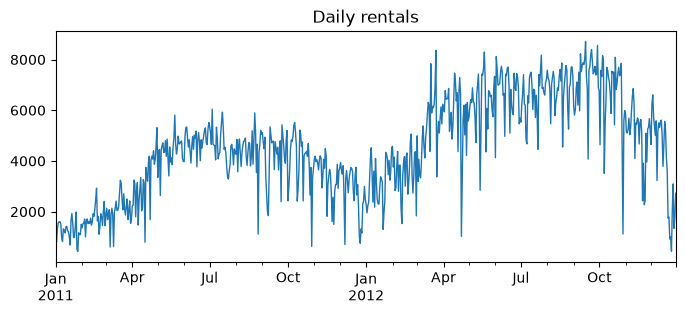

In [19]:
bikes = fetch_openml(data_id=42712, as_frame=True).frame
day_id = (bikes["hour"].diff() < 0).cumsum()          # a new day starts when the hour wraps
dates = pd.date_range("2011-01-01", periods=day_id.nunique(), freq="D")
series = pd.Series(bikes.groupby(day_id)["count"].sum().to_numpy(), index=dates, name="rentals")
series.plot(figsize=(8, 3), lw=1, title="Daily rentals");

In [20]:
lags = pd.concat({f"lag_{i}": series.shift(i) for i in range(1, 8)}, axis=1)
data_ts = pd.concat([lags, series.rename("target")], axis=1).dropna()
X_ts, y_ts = data_ts.drop(columns="target"), data_ts["target"]

reg = KNeighborsRegressor(n_neighbors=5)
for name, cv in [("KFold(shuffle=True)", KFold(5, shuffle=True, random_state=0)),
                 ("TimeSeriesSplit", TimeSeriesSplit(5))]:
    scores = cross_val_score(reg, X_ts, y_ts, cv=cv, scoring="r2")
    print(f"{name:20s} R^2 per fold: {np.round(scores, 2)}  mean={scores.mean():.2f}")

KFold(shuffle=True)  R^2 per fold: [0.75 0.73 0.69 0.67 0.72]  mean=0.71
TimeSeriesSplit      R^2 per fold: [-0.34  0.1   0.24 -1.25  0.53]  mean=-0.14


In [21]:
for fold, (tr, te) in enumerate(TimeSeriesSplit(5, gap=7).split(X_ts)):
    print(f"fold {fold}: train {X_ts.index[tr[0]].date()} .. {X_ts.index[tr[-1]].date()}"
          f" | test {X_ts.index[te[0]].date()} .. {X_ts.index[te[-1]].date()}")

fold 0: train 2011-01-08 .. 2011-05-03 | test 2011-05-11 .. 2011-09-07
fold 1: train 2011-01-08 .. 2011-08-31 | test 2011-09-08 .. 2012-01-05
fold 2: train 2011-01-08 .. 2011-12-29 | test 2012-01-06 .. 2012-05-04
fold 3: train 2011-01-08 .. 2012-04-27 | test 2012-05-05 .. 2012-09-01
fold 4: train 2011-01-08 .. 2012-08-25 | test 2012-09-02 .. 2012-12-30


---
## EXERCISE (Try it 2): Which splitter, and how big is the gap?

**In class, about 15 minutes.** We now use the *hourly* bike data with calendar and weather features.

1. **Before running anything**, write down your prediction: which splitter gives the higher R^2, and by roughly how much?
2. Run the cell. Was your guess right? Which number would you report to the bike operator, and why?
3. Add `TimeSeriesSplit(5, gap=24)` and `TimeSeriesSplit(5, max_train_size=24 * 180)` to the list. What changes, and why?
4. Bonus: drop the `year` column. Which splitter's score changes more? Explain.

In [22]:
# EXERCISE (Try it 2): features -- do not change
features = ["year", "month", "hour", "weekday", "temp", "humidity", "windspeed"]
X_hour = bikes[features].astype(float)
X_hour["workingday"] = (bikes["workingday"] == "True").astype(float)
y_hour = bikes["count"]
print(X_hour.shape)

(17379, 8)


In [23]:
# EXERCISE (Try it 2)
reg = KNeighborsRegressor(n_neighbors=10)
splitters = [("KFold(shuffle=True)", KFold(5, shuffle=True, random_state=0)),
             ("TimeSeriesSplit", TimeSeriesSplit(5)),
             # TODO: add ("TimeSeriesSplit(gap=24)", TimeSeriesSplit(5, gap=24)) and a max_train_size variant
             ]
cols = X_hour.columns            # TODO (bonus): try X_hour.columns.drop("year")
for name, cv in splitters:
    scores = cross_val_score(reg, X_hour[cols], y_hour, cv=cv, scoring="r2")
    print(f"{name:24s} mean R^2 = {scores.mean():.2f}  (folds: {np.round(scores, 2)})")

KFold(shuffle=True)      mean R^2 = 0.71  (folds: [0.7  0.71 0.72 0.71 0.7 ])


TimeSeriesSplit          mean R^2 = 0.45  (folds: [0.49 0.47 0.34 0.53 0.41])


## Summary

* Report the score of a procedure that mimics deployment, not the best score you saw.
* Choose the splitter from the question "what will the model see after deployment?": stratified for classification, grouped for repeated measurements, time-ordered for forecasting.
* Log the splitter together with the scores in MLflow; a number without its validation scheme is not interpretable.